<a href="https://colab.research.google.com/github/egpanetta/programming_90800/blob/main/final_exploratoryanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Data Overview and Summary:

The Pittsburgh Bureau of Police monthly crime incidents reports are rich datasets including over 34,000 entries and 20 different columns. Each entry details a unique crime, providing a comprehensive view of various aspects of the incident.

Key information in the dataset includes:

1. **Identifiers**: Unique IDs and report numbers for each incident.
2. **Temporal Data**: When the crime occurred, including the reported date, time, hour of the day, day of the week, and month.
3. **Crime Classification**: Detailed descriptions using the NIBRS (National Incident-Based Reporting System) codes, offense categories, types, and what the crime was 'against' (e.g., Person, Property, Society, or Group B). There's also a general 'Violation' description.
4. **Geographical Data:** Where the crime took place, specified by X and Y coordinates, police zone, census tract, neighborhood, and even a block address.

While most of the data is complete, some location-based columns like Tract, Neighborhood, XCOORD, and YCOORD have some missing values.


> https://data.wprdc.org/dataset/monthly-criminal-activity-dashboard
>>In addition to cited material throughout, Google Gemini was used in the creation of the donut pie chart and in formatting for other visualizations.


I wanted to look at this data because all the moments leading up to a crime, the crime itself, and the aftermath leave rippling affects in the communities they occur. States across the United States working tirelessly on evolving policies around crime prevention and policing, and I believe detailed data from reports like these should be used in that work. I do not believe that indescriminate addition of police to the streets or mass arrests will decrease crimes, but targetted preventative measures are known, researched, and effective. This report is an example of how data can direct intervention policies.

###Importing the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crime_df = pd.read_csv("/content/programming_90800/monthlycriminalactivitydashboard.csv")

/tmp/ipython-input-942653042.py:5: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_df = pd.read_csv("/content/programming_90800/monthlycriminalactivitydashboard.csv")


# Analysis of the When

Then, I wanted to understand *when* crimes are happening. This heatmap shows a large comparative overview of how many crimes were reported per day of the week by month.

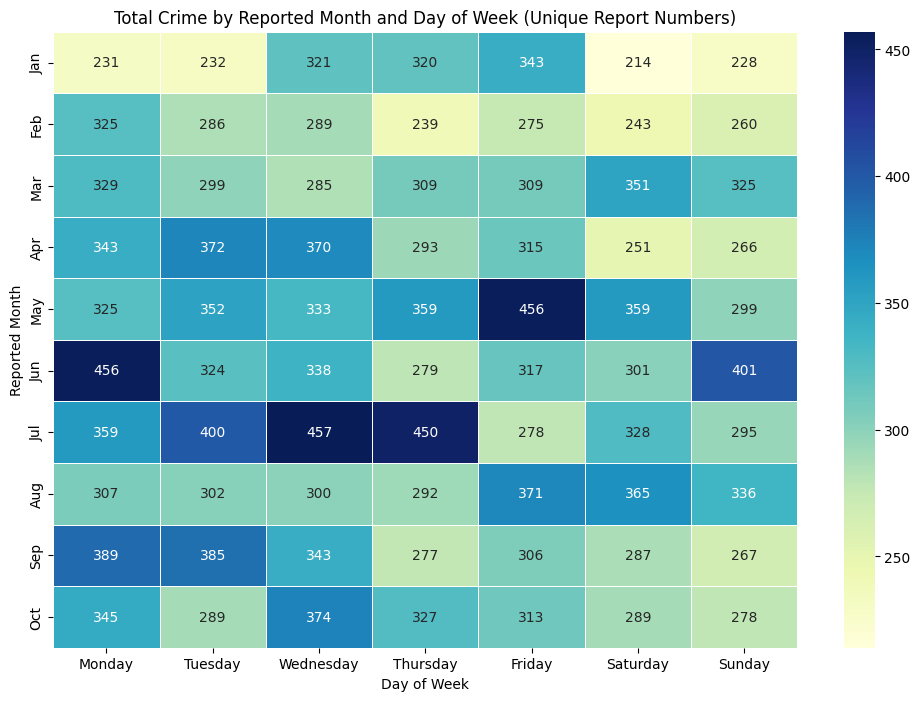

In [2]:
# counting unique 'Report_Number' for each 'ReportedMonth' and 'DayofWeek'
crime_heatmap_data = crime_df.groupby(['ReportedMonth', 'DayofWeek'])['Report_Number'].nunique().unstack(fill_value=0)

# set the order of days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
crime_heatmap_data = crime_heatmap_data[day_order]

# set order of months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Filter to only include months present in the data and reorder -- Change if Nov and Dec are added
present_months = [month for month in month_order if month in crime_heatmap_data.index]
crime_heatmap_data = crime_heatmap_data.reindex(present_months)

plt.figure(figsize=(12, 8))
sns.heatmap(crime_heatmap_data, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Total Crime by Reported Month and Day of Week (Unique Report Numbers)')
plt.xlabel('Day of Week')
plt.ylabel('Reported Month')
plt.show()

Based on the heatmap, here's a simple analysis of the crime patterns:

Monthly Trends: There appears to be a noticeable increase in crime incidents during the summer months, particularly July and August, which show the highest numbers across most days of the week. Conversely, January, February, and March generally exhibit lower crime activity.
Daily Trends: Across many months, Fridays tend to record the highest number of unique crime reports. While Mondays and Tuesdays also show significant activity, Saturdays and Sundays often have comparatively lower counts than weekdays, though there are variations (e.g., Saturday in March is notably high).

## Overall Hourly Crime Trend

I also wanted to visualize the overall hourly distribution of unique crime reports. Understanding *when* crimes happen is just as important as knowing *what* crimes happen. The chart showed how crime reports generally peak in the afternoon around 4 PM and are the lowest in the early morning hours, particularly around 5 AM.



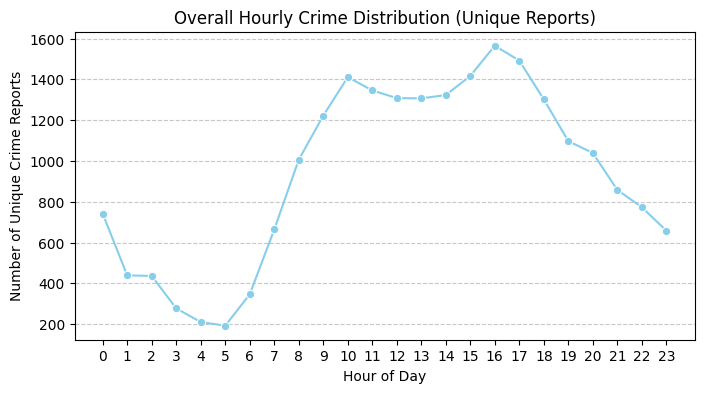

In [3]:
# group by 'Hour' and count unique 'Report_Number'
overall_crime_by_hour = crime_df.groupby('Hour')['Report_Number'].nunique().reset_index()

#plot
plt.figure(figsize=(8, 4))
sns.lineplot(x='Hour', y='Report_Number', data=overall_crime_by_hour, marker='o', color='skyblue')

# labels and title
plt.xlabel('Hour of Day')
plt.ylabel('Number of Unique Crime Reports')
plt.title('Overall Hourly Crime Distribution (Unique Reports)')
plt.xticks(range(0, 24)) # all hours are displayed on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#The Where
A look at this summary table shows the Central Business District had the highest crime report rate, and Brookline the fewest. The Central Business District, with 2122 incidents, has almost double the second-highest neighborhood, South Side Flats (1205 reports).

In [4]:
top_10_neighborhoods = crime_df.groupby('Neighborhood')['Report_Number'].nunique().reset_index()
top_10_neighborhoods = top_10_neighborhoods.sort_values(by='Report_Number', ascending=False).head(10)
print("\nTop 10 Neighborhoods by Unique Crime Reports:")
display(top_10_neighborhoods.rename(columns={'Report_number':'Number of Reports'}))


Top 10 Neighborhoods by Unique Crime Reports:


,Neighborhood,Report_Number
16,Central Business District,2122
72,South Side Flats,1205
69,Shadyside,762
15,Carrick,633
28,East Liberty,625
25,East Allegheny,521
9,Bloomfield,482
54,Mount Washington,424
2,Allentown,417
13,Brookline,415




The below bar chart provides a strong visualization of the crime distribution in different areas of Allegheny County.



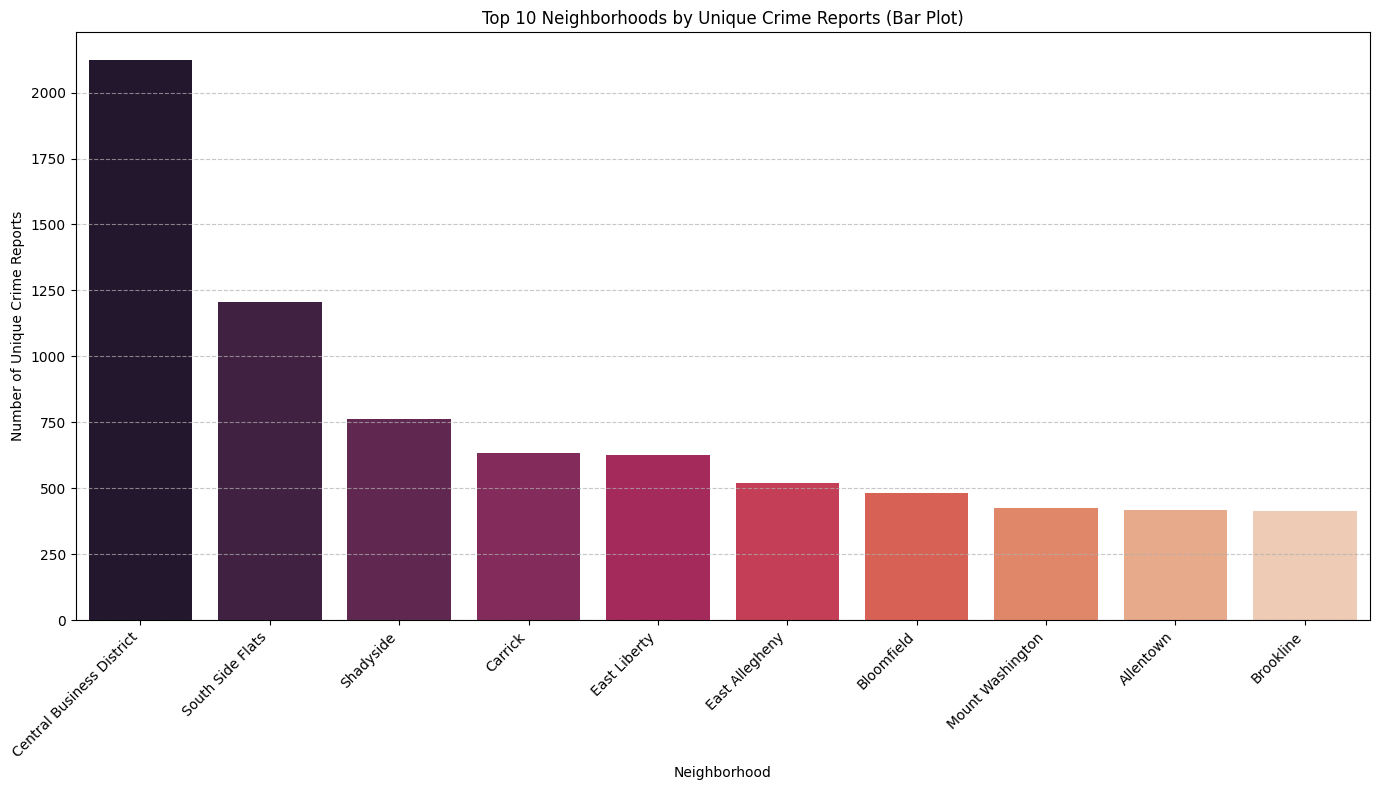

In [5]:
top_10_neighborhoods_sorted = top_10_neighborhoods.sort_values(by='Report_Number', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='Neighborhood', y='Report_Number', data=top_10_neighborhoods_sorted, palette='rocket', hue='Neighborhood', legend=False)

plt.xlabel('Neighborhood')
plt.ylabel('Number of Unique Crime Reports')
plt.title('Top 10 Neighborhoods by Unique Crime Reports (Bar Plot)')
plt.xticks(rotation=45, ha='right') # rotating x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() #  prevent labels from overlapping
plt.show()

There is enough detail in the dataset and concentration of crime for an analysis of what blocks of the county these crime reports are happening. The 400 Block of Smithfield Street stands out significantly with 217 unique reports, making it the highest crime block address. The 200 Block of 5th Ave Pittsburgh, PA and 6200 Block of Penn Avefollow with 170 and 146 reports, respectively, indicating these are also high-incident areas. Interventions should be further targetted to these locations.



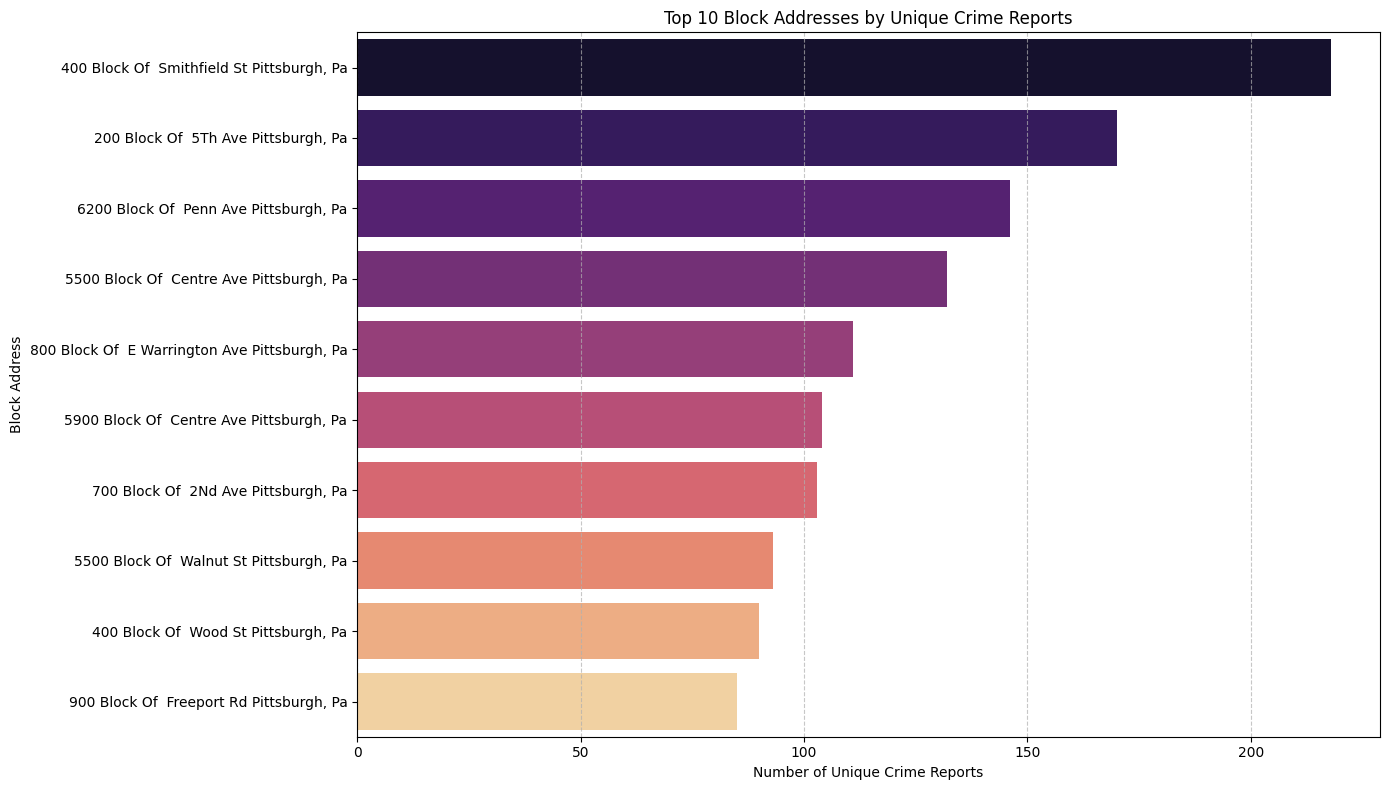

In [6]:
#Formatting
crime_df['Block_Address'] = crime_df['Block_Address'].str.title()

# group by 'Block_Address' and count unique 'Report_Number'
top_blocks_data = crime_df.groupby('Block_Address')['Report_Number'].nunique().reset_index()

# top 10 in descending order
top_10_blocks = top_blocks_data.sort_values(by='Report_Number', ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.barplot(x='Report_Number', y='Block_Address', data=top_10_blocks, palette='magma', hue='Block_Address', legend=False)

# title and labels
plt.xlabel('Number of Unique Crime Reports')
plt.ylabel('Block Address')
plt.title('Top 10 Block Addresses by Unique Crime Reports')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#Types of Crimes
Allegheny reports on crimes from arson to kidnapping. This data also contains categories "Not NIBRS Reportable" and "All other offenses," taking up almost 40% of the data. However, the remaining data is important to understand when thinking about potential crime interventions. Before visualizing the data, those non-informational categories were removed.

In [7]:
# filter the categories
top_10_offense_categories = crime_df.groupby('NIBRS_Offense_Category')['Report_Number'].nunique().reset_index()
specific_offenses = top_10_offense_categories[top_10_offense_categories['NIBRS_Offense_Category'].isin(['Not NIBRS Reportable', 'All other Offenses'])]

print("\nCounts for 'Not NIBRS Reportable' and 'All other Offenses':")
display(specific_offenses)

# total for these specific categories
total_specific_offenses = specific_offenses['Report_Number'].sum()

#total of all unique reports in the original crime_df to calculate percentages
total_all_reports = crime_df['Report_Number'].nunique()

# calc
percentage_not_nibrs = (specific_offenses[specific_offenses['NIBRS_Offense_Category'] == 'Not NIBRS Reportable']['Report_Number'].values[0] / total_all_reports) * 100
percentage_all_other = (specific_offenses[specific_offenses['NIBRS_Offense_Category'] == 'All other Offenses']['Report_Number'].values[0] / total_all_reports) * 100

summary_sentence = (
    f"The 'Not NIBRS Reportable' category accounts for {specific_offenses[specific_offenses['NIBRS_Offense_Category'] == 'Not NIBRS Reportable']['Report_Number'].values[0]} "
    f"unique crime reports ({percentage_not_nibrs:.1f}% of all unique reports), "
    f"while 'All other Offenses' accounts for {specific_offenses[specific_offenses['NIBRS_Offense_Category'] == 'All other Offenses']['Report_Number'].values[0]} "
    f"unique crime reports ({percentage_all_other:.1f}% of all unique reports).")
print(summary_sentence)



Counts for 'Not NIBRS Reportable' and 'All other Offenses':


,NIBRS_Offense_Category,Report_Number
0,All other Offenses,4291
12,Not NIBRS Reportable,4624


The 'Not NIBRS Reportable' category accounts for 4624 unique crime reports (20.6% of all unique reports), while 'All other Offenses' accounts for 4291 unique crime reports (19.1% of all unique reports).


After removing the reports labelled "Not NIBRS Reportable" and "All Other Offenses", this is the distribution of crime types:

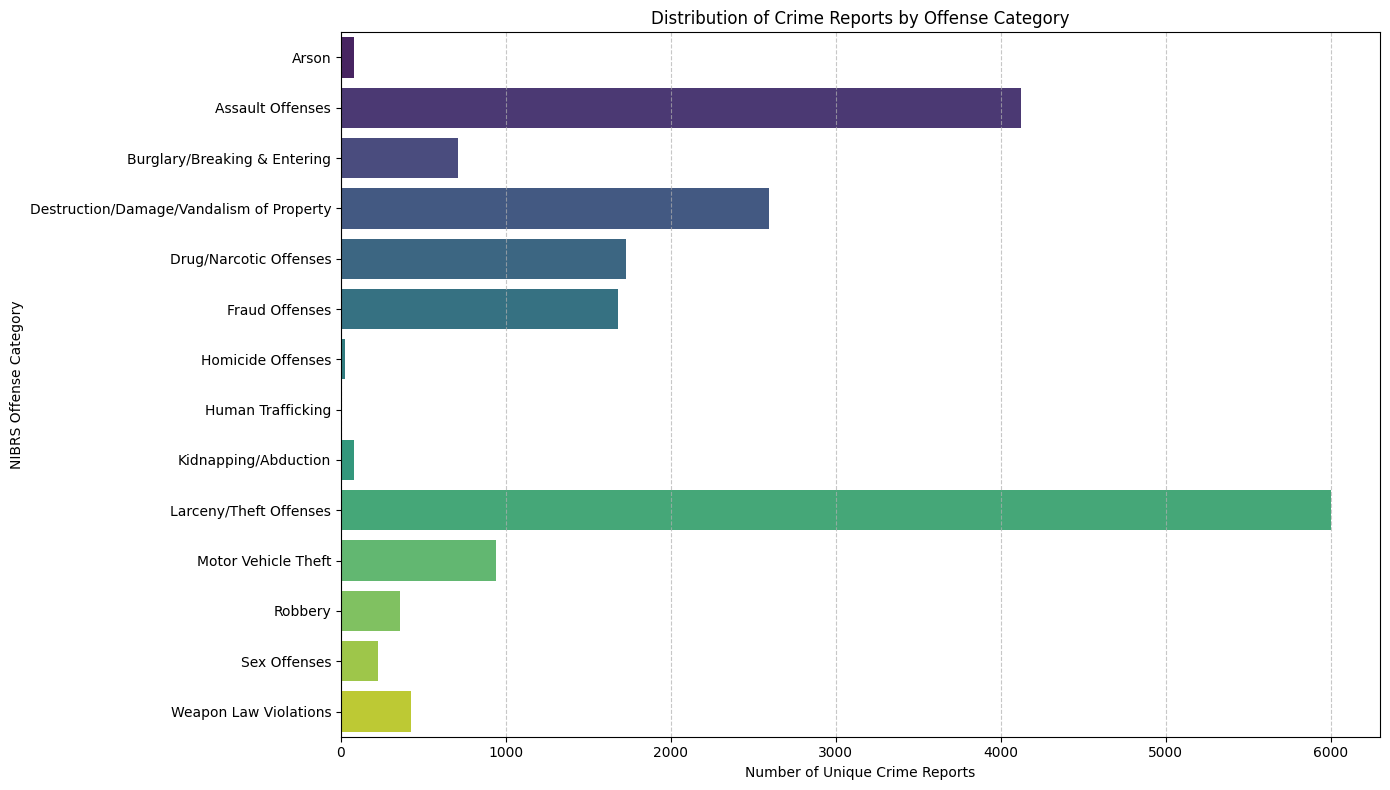

In [9]:
filtered_crime_df_types = crime_df[~crime_df['NIBRS_Offense_Category'].isin(['Not NIBRS Reportable', 'All other Offenses'])]
crime_by_offense_category = filtered_crime_df_types.groupby('NIBRS_Offense_Category')['Report_Number'].nunique().reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='Report_Number', y='NIBRS_Offense_Category', data=crime_by_offense_category, palette='viridis', hue='NIBRS_Offense_Category', legend=False)

plt.xlabel('Number of Unique Crime Reports')
plt.ylabel('NIBRS Offense Category')
plt.title('Distribution of Crime Reports by Offense Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Larceny and theft offenses are the most frequently reported crime category with assault offenses ranking as the second most common category. Categories like Motor Vehicle Theft and Burglary/Breaking & Entering are less frequent but still represent significant incidents. Categories such as Weapon Law Violations, Robbery, Sex Offenses, Kidnapping/Abduction, Arson, Homicide Offenses, and Human Trafficking occur with considerably lower frequencies, with Human Trafficking being the least reported offense category.

The high incidence of larceny/theft and assault offenses suggests these areas may benefit from targeted crime prevention strategies or resource allocation.
Further analysis could investigate the specific sub-categories or locations within the top reported offenses to identify localized patterns or contributing factors.

#Reporting the "Crimes Against" statistics
I wanted to look next at what the target of these crimes is.

###Understanding the categories:
While crimes against people and property are easily understanable, crimes against society and "Group B" are not clear. Crimes against society include gambling, prostitution, and drug violations, and are typically victimless crimes not targetted at an individual or property. Group B offenses are not reported (detailed), only the arrest data. To visualize the data, I made 2 donut pie charts, one including the Group B data, and one without.


National Incident-Based Reporting System (NIBRS). (2012). https://ucr.fbi.gov/nibrs/2012/resources/crimes-against-persons-property-and-society

In [11]:
# group by 'NIBRS_Crime_Against' and count unique 'Report_Number'
crime_by_nibrs_category = crime_df.groupby('NIBRS_Crime_Against')['Report_Number'].nunique().reset_index()
crime_by_nibrs_category = crime_by_nibrs_category.sort_values(by='Report_Number', ascending=False)

print("\nCounts for each NIBRS_Crime_Against category:")
display(crime_by_nibrs_category)


Counts for each NIBRS_Crime_Against category:


,NIBRS_Crime_Against,Report_Number
2,Property,11239
0,Group B,8313
1,Person,4367
3,Society,2017


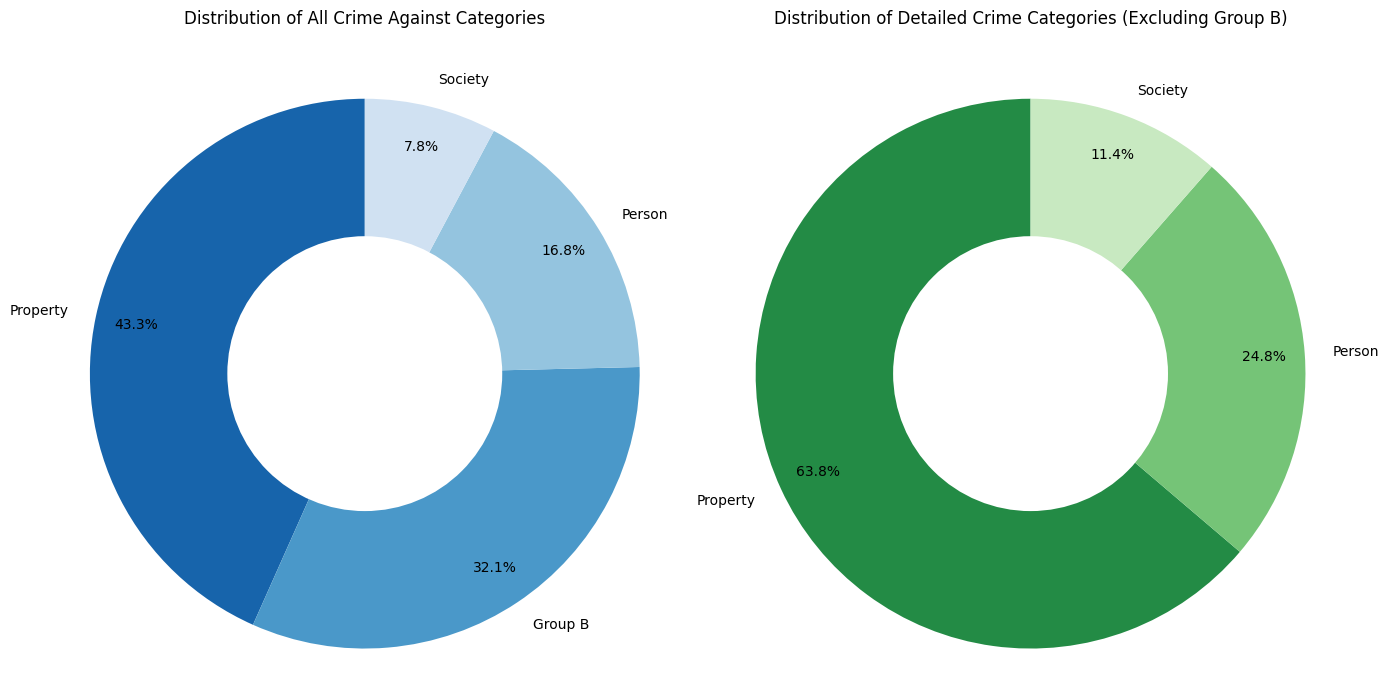

In [12]:
# chart excluding 'Group B'
crime_by_nibrs_category_filtered = crime_by_nibrs_category[crime_by_nibrs_category['NIBRS_Crime_Against'] != 'Group B']

# Create a figure with two subplots side-by-side. Adjusted figsize for better layout.
plt.figure(figsize=(14, 7))

# --- First Donut Chart: All Categories --- (Including Group B)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.pie(crime_by_nibrs_category['Report_Number'],
        labels=crime_by_nibrs_category['NIBRS_Crime_Against'],
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85,
        colors=sns.color_palette('Blues_r', len(crime_by_nibrs_category)))

# white circle in the middle to create a donut chart
centre_circle1 = plt.Circle((0,0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle1)
plt.title('Distribution of All Crime Against Categories', y=1.05) # Adjust y to move title closer
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.


# --- Second Donut Chart: Excluding Group B --- (Person, Property, Society)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.pie(crime_by_nibrs_category_filtered['Report_Number'],
        labels=crime_by_nibrs_category_filtered['NIBRS_Crime_Against'],
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85,
        colors=sns.color_palette('Greens_r', len(crime_by_nibrs_category_filtered)))

# white circle in the middle to create a donut chart
centre_circle2 = plt.Circle((0,0), 0.50, fc='white')
fig.gca().add_artist(centre_circle2)
plt.title('Distribution of Detailed Crime Categories (Excluding Group B)', y=1.05) # Adjust y to move title closer
plt.axis('equal')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


#Conclusion
Overall, the crime analysis shows that Allegheny County’s public safety challenges are heavily concentrated in property‐related offenses, which dominate both the overall crime composition and the highest-incident locations. There are high crime clusters around dense commercial corridors—especially the Central Business District, and general increases during warmer months, weekday afternoons, and peak foot-traffic hours.

Although violent crime represents a smaller proportion of total incidents, the persistent concentration of offenses in specific neighborhoods and blocks suggests spatially patterned risk that can be mitigated with targeted interventions. All together, these trends point to the need for localized, data-driven prevention strategies that address both opportunity-driven property crime and routine-activity patterns.

###Evidence-Based Crime Prevention Measures for Allegheny County

**Hot-Spots Policing With Problem-Oriented Strategies**

Braga, Papachristos, and Hureau (2014, Journal of Experimental Criminology) found that hot-spots policing—especially when combined with problem-oriented approaches—produces consistent and meaningful reductions in property and violent crime. Allegheny County could apply this by deploying targeted foot/bike patrols, environmental assessments, and problem-solving interventions around blocks like Smithfield St., 5th Ave., and Penn Ave.


> Braga, A. A., Papachristos, A. V., & Hureau, D. M. (2014). The effects of hot spots policing on crime: An updated systematic review and meta-analysis. Journal of Experimental Criminology, 10(4), 399–428. https://doi.org/10.1007/s11292-014-9210-y

*italicized text*
**Improved Environmental Design (CPTED) in High-Risk Commercial Corridors**

Enhanced lighting, clear sightlines, increased natural surveillance, and maintenance of public spaces—significantly reduce crime opportunities. A large randomized evaluation by Chalfin et al. (2021, PNAS) demonstrated that upgraded street lighting reduced nighttime crime by over 35% in treated areas. Implementing CPTED strategies in the Central Business District, South Side Flats, and Shadyside could reduce property crime by limiting opportunities and improving perceived safety.




>Chalfin, A., Hansen, B., Lerner, J., & Parker, L. (2021). Reducing crime through environmental design: Evidence from a randomized experiment of street lighting in New York City. Proceedings of the National Academy of Sciences, 118(50), e2019374118. https://doi.org/10.1073/pnas.2019374118


